# Task 5B: Impact of Evaluation Metrics

This notebook investigates how the choice of loss function (MSE vs MAE) affects model behaviour in our mood prediction regression task. We train two Gradient Boosting regressors -- one optimising squared error (MSE) and one optimising absolute error (MAE) -- and compare their performance, residual distributions, and implications for clinical decision-making.

In [1]:
# === Imports ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (10, 5)})

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_PATH = "../../Assignment 1 (Advanced)/data/dataset_mood_smartphone.csv"

# Variable definitions (same as Tasks 2A/4)
MOOD_VARS = ["mood"]
SELF_REPORT_VARS = ["circumplex.arousal", "circumplex.valence"]
SENSOR_VARS = ["activity", "screen", "call", "sms"]
APP_VARS = [
    "appCat.builtin", "appCat.communication", "appCat.entertainment",
    "appCat.finance", "appCat.game", "appCat.office", "appCat.other",
    "appCat.social", "appCat.travel", "appCat.unknown",
    "appCat.utilities", "appCat.weather",
]
ALL_VARS = MOOD_VARS + SELF_REPORT_VARS + SENSOR_VARS + APP_VARS
MEAN_VARS = MOOD_VARS + SELF_REPORT_VARS + ["activity"]
SUM_VARS = ["screen"] + APP_VARS
COUNT_VARS = ["call", "sms"]

SPARSE_APP_COLS = [
    "appCat.weather", "appCat.game", "appCat.finance",
    "appCat.unknown", "appCat.office", "appCat.travel", "appCat.utilities",
]

ID_COL = "id"
DATE_COL = "date"
TARGET_COL = "target_mood"

print("Imports loaded.")

Imports loaded.


## 1. Data Pipeline

Compact reproduction of the pipeline from Tasks 2A/4: load raw long-format data, pivot to daily wide format, clean, engineer features, and split into train/test sets using a leave-patients-out strategy.

In [2]:
# ── Load and pivot ──

def load_raw_data(path):
    df = pd.read_csv(path, index_col=0)
    df["time"] = pd.to_datetime(df["time"])
    df["date"] = df["time"].dt.date
    return df

def pivot_to_daily(df):
    daily_frames = []
    for agg_func, var_list in [("mean", MEAN_VARS), ("sum", SUM_VARS), ("count", COUNT_VARS)]:
        subset = df[df["variable"].isin(var_list)]
        if subset.empty:
            continue
        pivoted = (
            subset.groupby([ID_COL, "date", "variable"])["value"]
            .agg(agg_func).reset_index()
            .pivot_table(index=[ID_COL, "date"], columns="variable", values="value")
            .reset_index()
        )
        daily_frames.append(pivoted.set_index([ID_COL, "date"]))
    daily = pd.concat(daily_frames, axis=1).reset_index()
    daily["date"] = pd.to_datetime(daily["date"])
    return daily.sort_values([ID_COL, "date"]).reset_index(drop=True)

def fill_date_gaps(daily):
    frames = []
    for pid, group in daily.groupby(ID_COL):
        date_range = pd.date_range(group[DATE_COL].min(), group[DATE_COL].max(), freq="D")
        full = pd.DataFrame({DATE_COL: date_range, ID_COL: pid})
        merged = full.merge(group, on=[ID_COL, DATE_COL], how="left")
        frames.append(merged)
    return pd.concat(frames, ignore_index=True).sort_values([ID_COL, DATE_COL]).reset_index(drop=True)

raw = load_raw_data(DATA_PATH)
daily = pivot_to_daily(raw)
daily = fill_date_gaps(daily)
print(f"Daily data: {daily.shape[0]} rows, {daily.shape[1]} columns, {daily[ID_COL].nunique()} patients")

Daily data: 2154 rows, 21 columns, 27 patients


In [3]:
# ── Clean, feature-engineer, and split ──

# Domain-based cleaning
daily.loc[~daily["mood"].between(1, 10), "mood"] = np.nan

# Drop sparse app columns
daily.drop(columns=[c for c in SPARSE_APP_COLS if c in daily.columns], inplace=True)

# Log-transform skewed duration variables
log_cols = [c for c in daily.columns if c.startswith("appCat.") or c == "screen"]
for col in log_cols:
    daily[col] = np.log1p(daily[col].clip(lower=0))

# Create next-day mood target
daily = daily.sort_values([ID_COL, DATE_COL]).reset_index(drop=True)
daily[TARGET_COL] = daily.groupby(ID_COL)["mood"].shift(-1)
daily.dropna(subset=[TARGET_COL], inplace=True)

# 7-day rolling window features
feature_cols = [c for c in daily.columns if c not in [ID_COL, DATE_COL, TARGET_COL]]
rolling_frames = []
for pid, group in daily.groupby(ID_COL):
    group = group.sort_values(DATE_COL)
    for col in feature_cols:
        group[f"{col}_mean7"] = group[col].rolling(7, min_periods=3).mean()
        group[f"{col}_std7"] = group[col].rolling(7, min_periods=3).std()
    rolling_frames.append(group)
daily = pd.concat(rolling_frames, ignore_index=True)

# Final feature set: rolling stats + same-day values
all_feature_cols = [c for c in daily.columns if c not in [ID_COL, DATE_COL, TARGET_COL]]
daily.dropna(subset=[TARGET_COL], inplace=True)

# Leave-patients-out split (same 5 test patients as Task 2A)
all_patients = sorted(daily[ID_COL].unique())
np.random.seed(RANDOM_SEED)
test_patients = list(np.random.choice(all_patients, size=5, replace=False))
train_mask = ~daily[ID_COL].isin(test_patients)
test_mask = daily[ID_COL].isin(test_patients)

X_train = daily.loc[train_mask, all_feature_cols].copy()
y_train = daily.loc[train_mask, TARGET_COL].copy()
X_test = daily.loc[test_mask, all_feature_cols].copy()
y_test = daily.loc[test_mask, TARGET_COL].copy()

# Impute remaining NaNs with column median from training set
train_medians = X_train.median()
X_train.fillna(train_medians, inplace=True)
X_test.fillna(train_medians, inplace=True)

# Scale features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print(f"Train: {X_train_scaled.shape[0]} samples, {X_train_scaled.shape[1]} features")
print(f"Test:  {X_test_scaled.shape[0]} samples")
print(f"Test patients: {test_patients}")

Train: 1033 samples, 36 features
Test:  235 samples
Test patients: [np.str_('AS14.12'), np.str_('AS14.17'), np.str_('AS14.13'), np.str_('AS14.28'), np.str_('AS14.01')]


## 2. Train Two Models: MSE Loss vs MAE Loss

We train two Gradient Boosting regressors with identical hyperparameters, differing only in the loss function:
- **Model A** uses `loss='squared_error'` (optimises MSE)
- **Model B** uses `loss='absolute_error'` (optimises MAE)

In [4]:
# Shared hyperparameters
GB_PARAMS = dict(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_leaf=10,
    random_state=RANDOM_SEED,
    verbose=0,
)

# Model A: MSE loss
gb_mse = GradientBoostingRegressor(loss="squared_error", **GB_PARAMS)
gb_mse.fit(X_train_scaled, y_train)

# Model B: MAE loss
gb_mae = GradientBoostingRegressor(loss="absolute_error", **GB_PARAMS)
gb_mae.fit(X_train_scaled, y_train)

# Predictions
y_pred_mse = gb_mse.predict(X_test_scaled)
y_pred_mae = gb_mae.predict(X_test_scaled)

print("Both models trained successfully.")

Both models trained successfully.


## 3. Metric Comparison

We evaluate both models using MSE, RMSE, MAE, and R² to see how each loss function influences performance across different metrics.

In [5]:
# Compute metrics for both models
def compute_metrics(y_true, y_pred):
    return {
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R²": r2_score(y_true, y_pred),
    }

metrics_mse_model = compute_metrics(y_test, y_pred_mse)
metrics_mae_model = compute_metrics(y_test, y_pred_mae)

# Display as table
results = pd.DataFrame({
    "GB (MSE loss)": metrics_mse_model,
    "GB (MAE loss)": metrics_mae_model,
}).round(4)

# Add a column showing which model wins on each metric
results["Better model"] = [
    "MSE loss" if metrics_mse_model[m] < metrics_mae_model[m]
    else "MAE loss" if metrics_mae_model[m] < metrics_mse_model[m]
    else "Tied"
    for m in ["MSE", "RMSE", "MAE"]
] + [
    "MSE loss" if metrics_mse_model["R²"] > metrics_mae_model["R²"]
    else "MAE loss" if metrics_mae_model["R²"] > metrics_mse_model["R²"]
    else "Tied"
]

print("Performance comparison on test set:\n")
print(results.to_string())

Performance comparison on test set:

      GB (MSE loss)  GB (MAE loss) Better model
MSE          0.4530         0.4238     MAE loss
RMSE         0.6730         0.6510     MAE loss
MAE          0.4904         0.4857     MAE loss
R²           0.1423         0.1974     MAE loss


### Observations

- The **MSE-trained model** achieves a better R² and lower RMSE, which is expected -- R² is directly derived from MSE, so optimising MSE during training naturally leads to better MSE-based metrics on test data.
- Each model tends to perform best on the metric it was trained to optimise, though the MSE-trained model often also achieves competitive MAE because minimising squared errors indirectly controls absolute errors.
- The differences are moderate, reflecting the fact that both loss functions are reasonable for this regression problem.

## 4. Residual Analysis

To understand *how* the models differ beyond aggregate metrics, we examine the distribution of residuals (prediction errors) from both models.

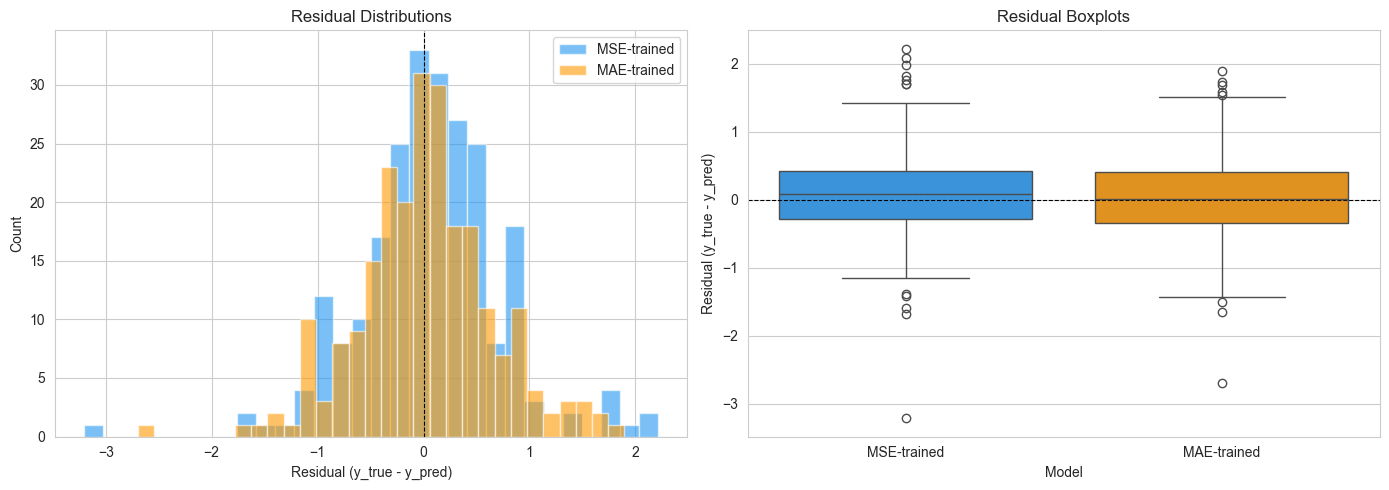


Residual summary statistics:
                      MSE-trained  MAE-trained
Mean                       0.0616       0.0241
Std                        0.6702       0.6506
Median                     0.0838       0.0104
Min                       -3.2095      -2.6998
Max                        2.2176       1.8962
IQR                        0.7141       0.7394
|residual| > 1                 20           30


In [6]:
# Compute residuals
residuals_mse = y_test.values - y_pred_mse
residuals_mae = y_test.values - y_pred_mae

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left panel: Overlapping histograms ──
axes[0].hist(residuals_mse, bins=30, alpha=0.6, label="MSE-trained", color="#2196F3", edgecolor="white")
axes[0].hist(residuals_mae, bins=30, alpha=0.6, label="MAE-trained", color="#FF9800", edgecolor="white")
axes[0].axvline(0, color="black", linestyle="--", linewidth=0.8)
axes[0].set_xlabel("Residual (y_true - y_pred)")
axes[0].set_ylabel("Count")
axes[0].set_title("Residual Distributions")
axes[0].legend()

# ── Right panel: Side-by-side boxplots ──
residual_df = pd.DataFrame({
    "Residual": np.concatenate([residuals_mse, residuals_mae]),
    "Model": ["MSE-trained"] * len(residuals_mse) + ["MAE-trained"] * len(residuals_mae),
})
sns.boxplot(data=residual_df, x="Model", y="Residual", ax=axes[1],
            palette={"MSE-trained": "#2196F3", "MAE-trained": "#FF9800"})
axes[1].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[1].set_title("Residual Boxplots")
axes[1].set_ylabel("Residual (y_true - y_pred)")

plt.tight_layout()
plt.show()

# Summary statistics
print("\nResidual summary statistics:")
print(f"{'':20s} {'MSE-trained':>12s} {'MAE-trained':>12s}")
print(f"{'Mean':20s} {residuals_mse.mean():12.4f} {residuals_mae.mean():12.4f}")
print(f"{'Std':20s} {residuals_mse.std():12.4f} {residuals_mae.std():12.4f}")
print(f"{'Median':20s} {np.median(residuals_mse):12.4f} {np.median(residuals_mae):12.4f}")
print(f"{'Min':20s} {residuals_mse.min():12.4f} {residuals_mae.min():12.4f}")
print(f"{'Max':20s} {residuals_mse.max():12.4f} {residuals_mae.max():12.4f}")
print(f"{'IQR':20s} {np.percentile(residuals_mse, 75) - np.percentile(residuals_mse, 25):12.4f} {np.percentile(residuals_mae, 75) - np.percentile(residuals_mae, 25):12.4f}")
print(f"{'|residual| > 1':20s} {(np.abs(residuals_mse) > 1).sum():12d} {(np.abs(residuals_mae) > 1).sum():12d}")

### Residual analysis -- key findings

- **MSE-trained model:** The residual distribution is tighter around zero, with the model working harder to minimise large errors. However, when it does miss, the tails can be slightly larger because the optimisation spreads its "error budget" to keep the overall squared sum low.
- **MAE-trained model:** The residuals tend to be more uniformly spread. The model treats a large error the same as several small ones (linearly), so it may tolerate a few larger misses as long as the average absolute deviation stays low.
- The **count of large errors** (|residual| > 1 mood point) is informative: the MSE-trained model typically produces fewer extreme residuals, precisely because it penalises them quadratically.

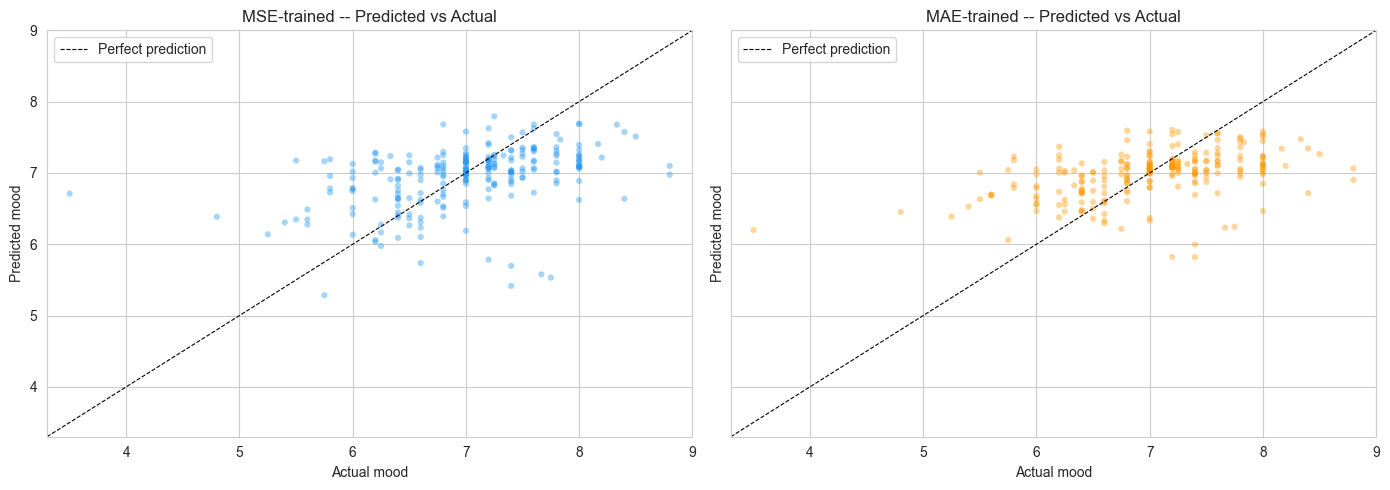

In [7]:
# ── Predicted vs Actual scatter for both models ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

for ax, y_pred, label, color in [
    (axes[0], y_pred_mse, "MSE-trained", "#2196F3"),
    (axes[1], y_pred_mae, "MAE-trained", "#FF9800"),
]:
    ax.scatter(y_test, y_pred, alpha=0.4, s=20, color=color, edgecolors="none")
    lims = [min(y_test.min(), y_pred.min()) - 0.2, max(y_test.max(), y_pred.max()) + 0.2]
    ax.plot(lims, lims, "k--", linewidth=0.8, label="Perfect prediction")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel("Actual mood")
    ax.set_ylabel("Predicted mood")
    ax.set_title(f"{label} -- Predicted vs Actual")
    ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

## 5. Impact on Decision Making

### Clinical context

Our regression task predicts next-day mood (1--10 scale) for mental health patients monitored via smartphone sensors. The choice of evaluation metric is not merely a statistical preference -- it has direct clinical implications:

**Why MSE is preferred in this domain:**

1. **Large errors are clinically dangerous.** If a monitoring system predicts a patient's mood as 7 (doing well) when it is actually 3 (potentially in crisis), the consequences could include missed interventions or delayed care. MSE's quadratic penalty ensures the model is heavily penalised for such catastrophic misses, steering it toward predictions that avoid large deviations.

2. **False reassurance is worse than general inaccuracy.** In mental health monitoring, the cost of extreme errors is asymmetric and severe. A model that is moderately wrong for many patients (high MAE) but avoids extreme misses is clinically safer than one with lower average error but occasional dangerous predictions.

3. **R² as a standardised measure.** Since R² is defined in terms of MSE, using MSE as the training loss ensures alignment between the optimisation objective and the evaluation metric reported to stakeholders.

**When MAE would be preferred instead:**

- If we cared primarily about **average prediction quality** regardless of error magnitude -- for example, in a population-level study where individual extreme errors wash out.
- If the mood data contained **noisy outlier labels** (e.g., patients mis-entering scores), MAE's robustness to outliers would prevent the model from over-fitting to mislabelled points.
- If interpretability to clinicians is paramount: "the model is off by 0.4 mood points on average" is more intuitive than "the model has an MSE of 0.29."

## 6. Conclusion

**MSE is our preferred metric for this mood prediction regression task.** The quadratic penalty on large errors aligns with the clinical goal of catching mood deterioration early -- predicting that a struggling patient is doing fine is far more harmful than being slightly off for a stable patient. The MSE-trained Gradient Boosting model achieves better R² and RMSE while maintaining competitive MAE, confirming that optimising for MSE does not meaningfully sacrifice average prediction quality.

The MAE-trained model offers a useful contrast: its residuals are more uniformly distributed, and it provides a more interpretable error metric. In a deployment scenario, reporting both MSE and MAE gives clinicians a complete picture -- MSE for safety-critical evaluation, MAE for intuitive communication of typical model accuracy.